In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

data = pd.read_csv('Mall_Customers.csv')
data_numeric = data.drop(columns=['CustomerID','Gender'])
#data_numeric['Gender'] = data_numeric['Gender'].map({'Male': 0, 'Female': 1})

In [3]:
data_numeric.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Resumen estadístico:
               Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


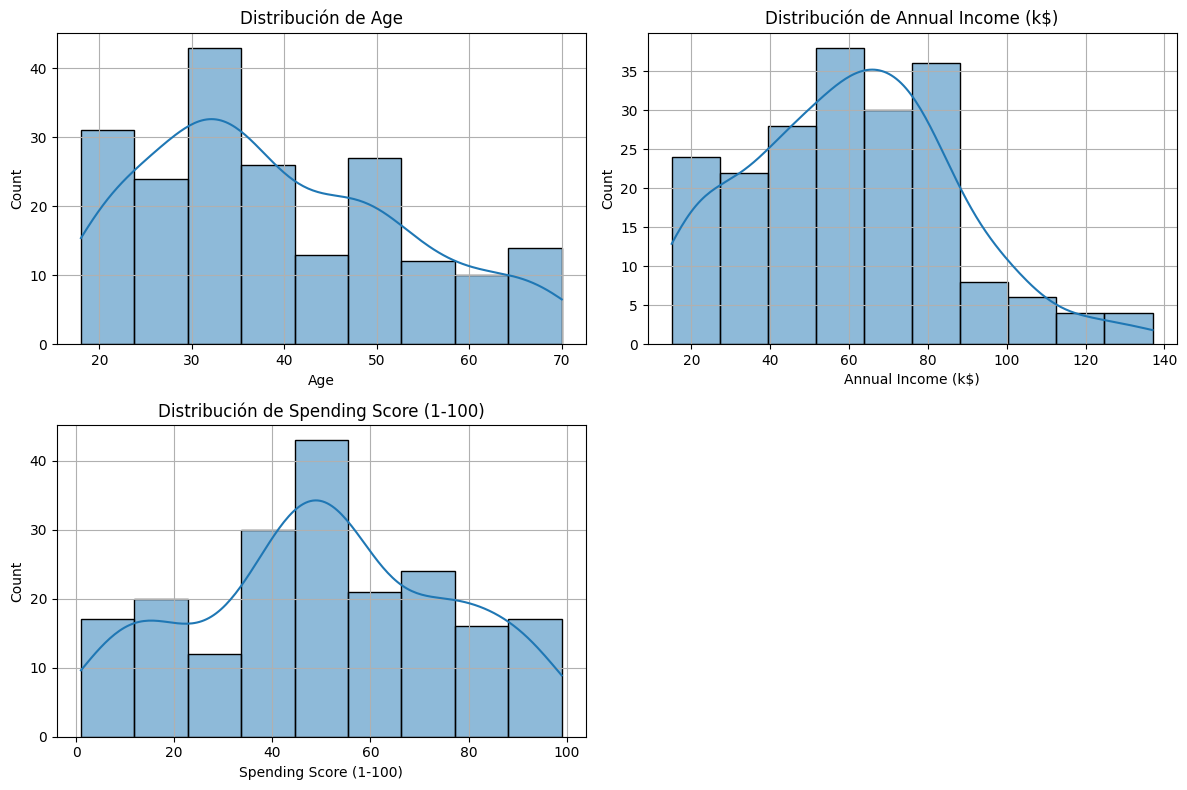

In [ ]:

print("Resumen estadístico:\n", data_numeric.describe())

num_vars = len(data_numeric.columns)
cols = 2
rows = (num_vars + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()


for i, col in enumerate(data_numeric.columns):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}')
    axes[i].grid(True)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


/var/folders/_2/b07hnlxx27j566j7xpz5w05m0000gn/T/ipykernel_6391/2048600234.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


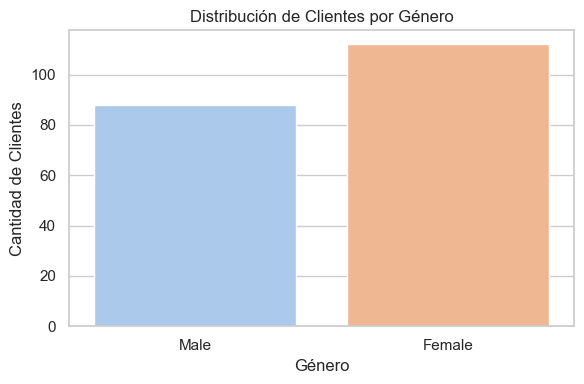

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Mall_Customers.csv')
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette='pastel')
plt.title('Distribución de Clientes por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.show()

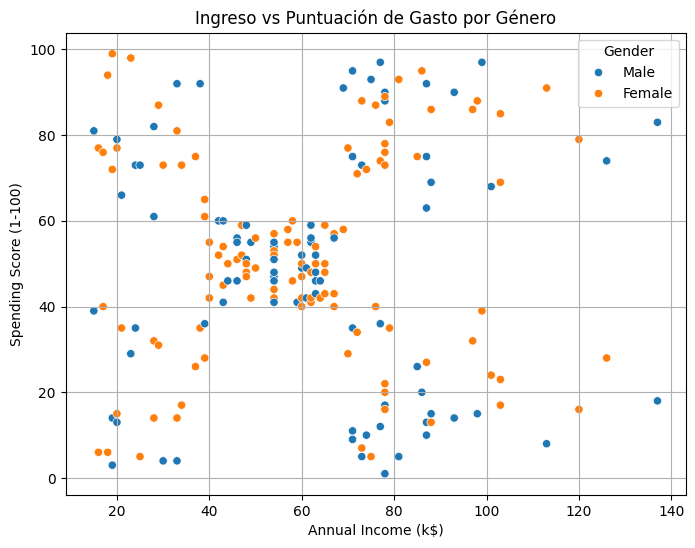

In [3]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender')
plt.title('Ingreso vs Puntuación de Gasto por Género')
plt.grid(True)
plt.show()

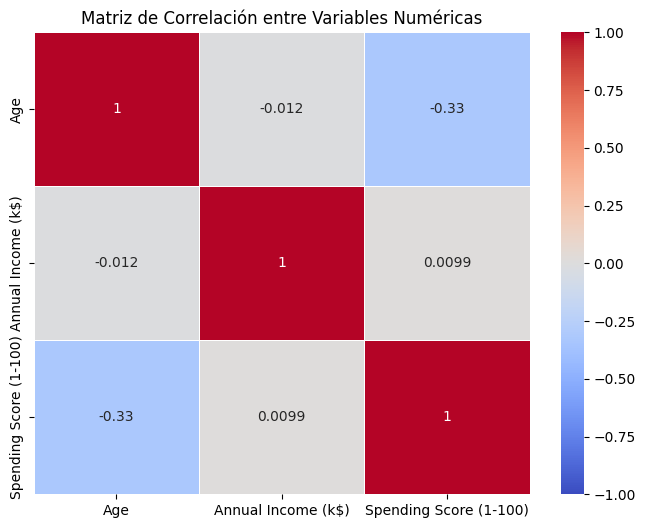


Interpretación de correlaciones destacadas:


In [ ]:

import numpy as np
correlation_matrix = data_numeric.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()
print("\nInterpretación de correlaciones destacadas:")
for col in correlation_matrix.columns:
    for idx in correlation_matrix.index:
        val = correlation_matrix.loc[idx, col]
        if idx != col and abs(val) > 0.5:
            print(f"- {idx} vs {col}: correlación {'positiva' if val > 0 else 'negativa'} de {val:.2f}")

In [5]:

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

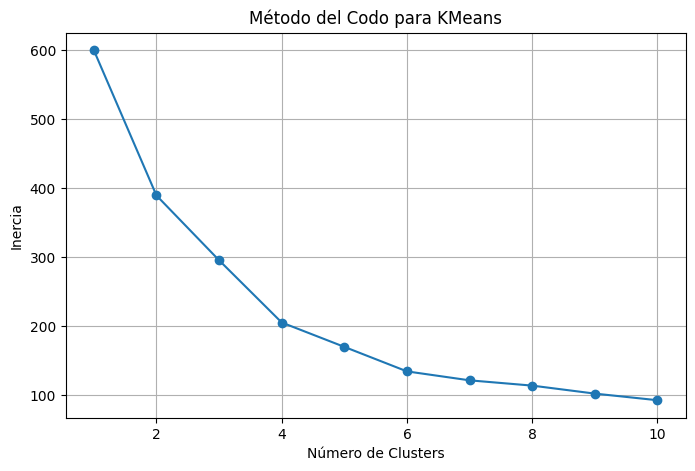

In [6]:
inertia = []
for n in range(1, 11):
    kmeans = KMeans(n_clusters=n, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para KMeans')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
data['KMeans_Cluster'] = kmeans.fit_predict(data_scaled)

dbscan = DBSCAN(eps=0.5, min_samples=5)
data['DBSCAN_Cluster'] = dbscan.fit_predict(data_scaled)

In [7]:

pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_scaled)
data['PCA1'], data['PCA2'] = pca_result[:, 0], pca_result[:, 1]

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(data_scaled)
data['TSNE1'], data['TSNE2'] = tsne_result[:, 0], tsne_result[:, 1]
unique_clusters = sorted(data['DBSCAN_Cluster'].unique())
palette_dbscan = {cl: sns.color_palette('tab10')[i % 10] for i, cl in enumerate(unique_clusters) if cl != -1}
palette_dbscan[-1] = 'black'

/Users/sebastianulloa/.virtualenvs/py310/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


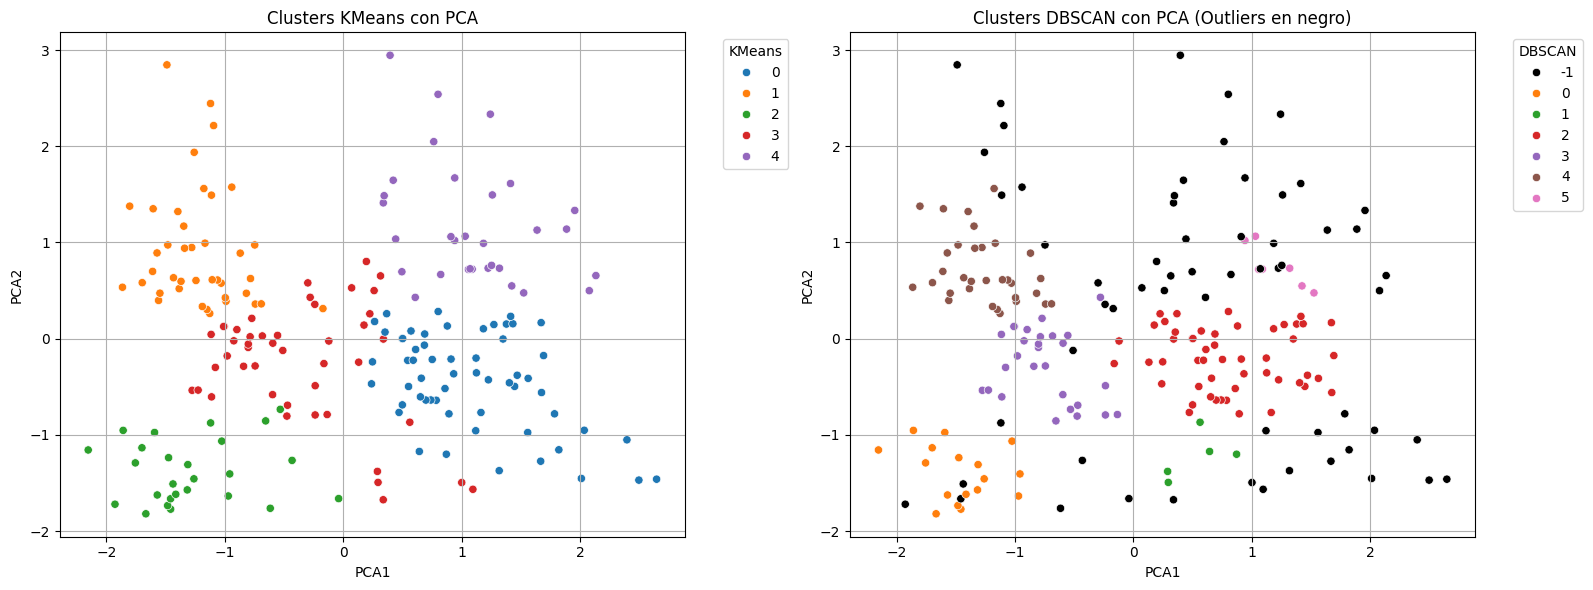

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=data, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='tab10', ax=axes[0])
axes[0].set_title('Clusters KMeans con PCA')
axes[0].grid(True)
axes[0].legend(title='KMeans', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.scatterplot(data=data, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette=palette_dbscan, ax=axes[1])
axes[1].set_title('Clusters DBSCAN con PCA (Outliers en negro)')
axes[1].grid(True)
axes[1].legend(title='DBSCAN', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

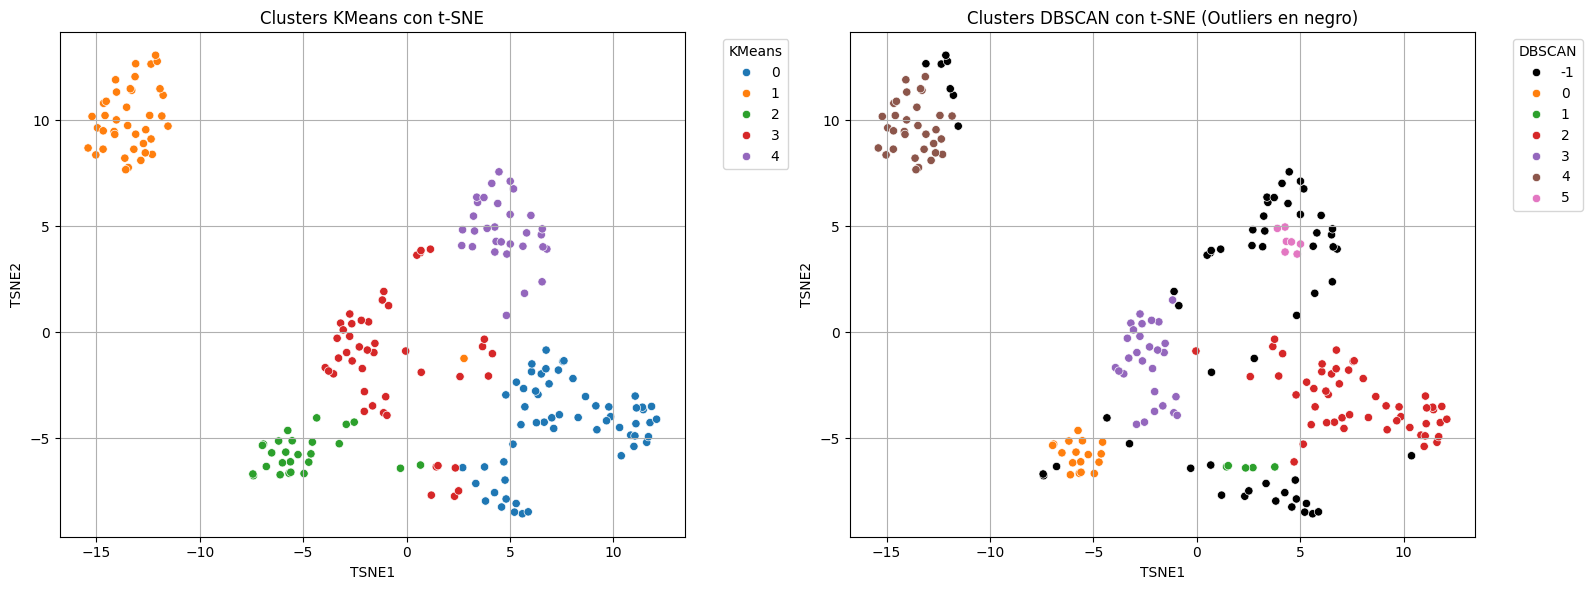

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=data, x='TSNE1', y='TSNE2', hue='KMeans_Cluster', palette='tab10', ax=axes[0])
axes[0].set_title('Clusters KMeans con t-SNE')
axes[0].grid(True)
axes[0].legend(title='KMeans', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.scatterplot(data=data, x='TSNE1', y='TSNE2', hue='DBSCAN_Cluster', palette=palette_dbscan, ax=axes[1])
axes[1].set_title('Clusters DBSCAN con t-SNE (Outliers en negro)')
axes[1].grid(True)
axes[1].legend(title='DBSCAN', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
data_numeric.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [10]:
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,DBSCAN_Cluster,PCA1,PCA2,TSNE1,TSNE2
0,1,Male,19,15,39,2,-1,-0.615720,-1.763481,-0.295240,-6.421681
1,2,Male,21,15,81,2,0,-1.665793,-1.820747,-6.111974,-6.727584
2,3,Female,20,16,6,3,-1,0.337862,-1.674799,1.197255,-7.689758
3,4,Female,23,16,77,2,0,-1.456573,-1.772430,-5.680000,-6.657175
4,5,Female,31,17,40,2,-1,-0.038465,-1.662740,0.673421,-6.270170
...,...,...,...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,-1,-1.093705,2.215577,-12.355040,12.643703
196,197,Female,45,126,28,4,-1,0.800448,2.540748,5.010921,7.118686
197,198,Male,32,126,74,1,-1,-1.119709,2.445169,-12.055229,12.775166
198,199,Male,32,137,18,4,-1,0.395411,2.946665,4.468378,7.560358


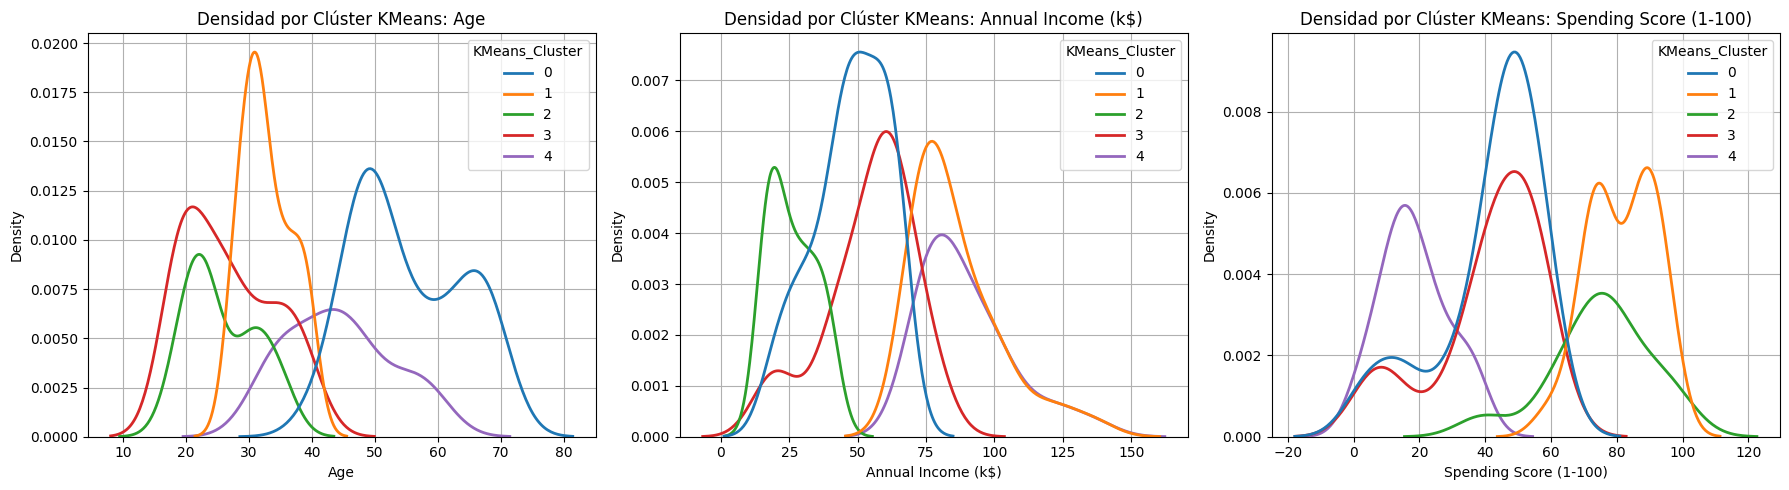

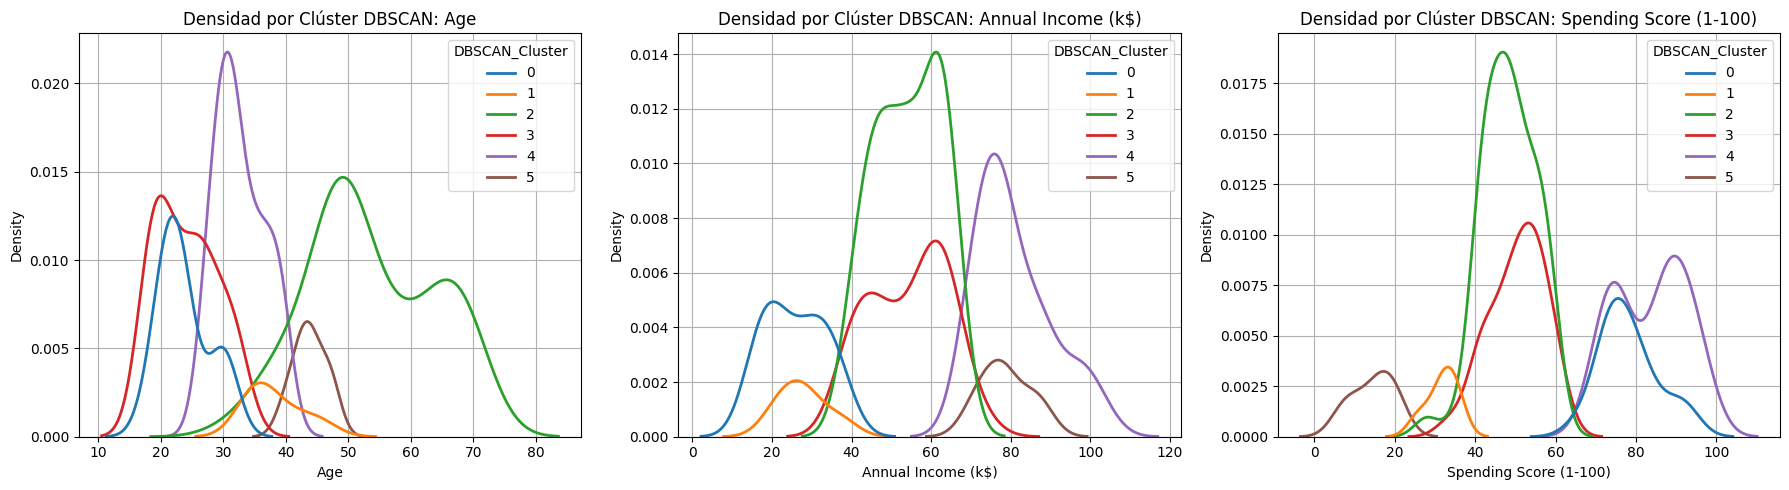

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

variables = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})
# Gráficos KMeans
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(variables):
    sns.kdeplot(data=data, x=col, hue='KMeans_Cluster', ax=axes[i],
                palette='tab10', linewidth=2)
    axes[i].set_title(f'Densidad por Clúster KMeans: {col}')
    axes[i].grid(True)
plt.tight_layout()
plt.show()

# Gráficos DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(variables):
    sns.kdeplot(data=data[data['DBSCAN_Cluster'] != -1], x=col, hue='DBSCAN_Cluster', ax=axes[i],
                palette='tab10', linewidth=2)
    axes[i].set_title(f'Densidad por Clúster DBSCAN: {col}')
    axes[i].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

variables = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


dbscan_profiles = data[data['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[variables].mean()

kmeans_profiles = data.groupby('KMeans_Cluster')[variables].mean()


fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'polar'}, {'type': 'polar'}]],
    subplot_titles=['DBSCAN Clusters', 'KMeans Clusters']
)


for cluster_id, row in dbscan_profiles.iterrows():
    fig.add_trace(
        go.Scatterpolar(
            r=row.values.tolist() + [row.values[0]],
            theta=variables + [variables[0]],
            fill='toself',
            name=f'DBSCAN {cluster_id}',
            subplot='polar'
        ),
        row=1, col=1
    )


for cluster_id, row in kmeans_profiles.iterrows():
    fig.add_trace(
        go.Scatterpolar(
            r=row.values.tolist() + [row.values[0]],
            theta=variables + [variables[0]],
            fill='toself',
            name=f'KMeans {cluster_id}',
            subplot='polar2'
        ),
        row=1, col=2
    )

fig.update_layout(
    title_text='Comparación de Perfiles Promedio por Clúster (Radar Chart)',
    showlegend=True,
    height=600,
    width=1000
)

fig.show()